In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import os
import random
import tensorflow 
from sklearn.metrics import (confusion_matrix, 
                             precision_score, 
                             recall_score, 
                             f1_score, 
                             roc_auc_score,
                             accuracy_score,
                             classification_report)
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow import data
from tensorflow.keras.applications import ResNet152
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.callbacks import (ModelCheckpoint, 
                                        ReduceLROnPlateau, 
                                        EarlyStopping, 
                                        TensorBoard)
import warnings
warnings.filterwarnings('ignore')

In [49]:
train_dir = '/kaggle/input/datasets/nihshu/propcessed-brain-tumor/brain_mri_tumor_prprocessed/train'
test_dir = '/kaggle/input/datasets/nihshu/propcessed-brain-tumor/brain_mri_tumor_prprocessed/test'

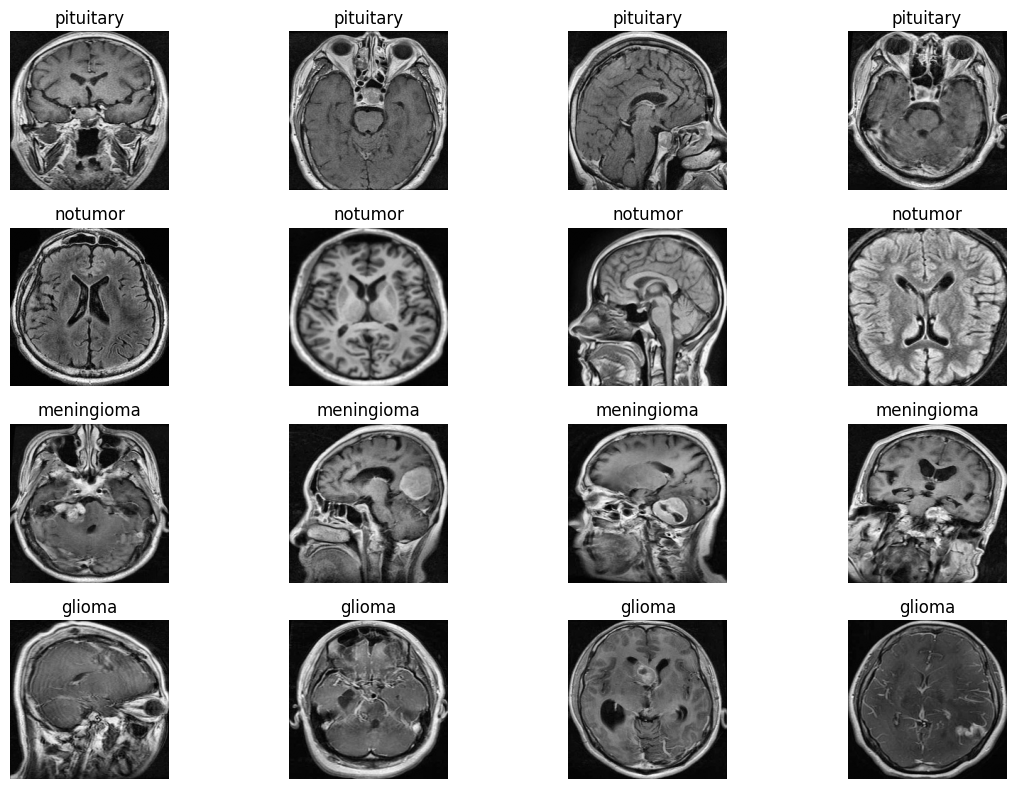

In [50]:
number_of_imgs = 4
classes = os.listdir(train_dir)

plt.figure(figsize = (12, 8))
i = 1

for cls in classes:
    path = os.path.join(train_dir, cls)
    imgs = random.sample(os.listdir(path), 
                         min(number_of_imgs, len(os.listdir(path))))
    
    for img in imgs:
        plt.subplot(len(classes), number_of_imgs, i)
        plt.imshow(Image.open(os.path.join(path, img)), cmap = 'gray')
        plt.title(cls)
        plt.axis('off')
        i += 1

plt.tight_layout()
plt.show()

# DATA PREPARATION 

In [51]:
train_ds, val_ds = image_dataset_from_directory(train_dir, 
                                                labels = 'inferred', 
                                                label_mode = 'categorical', 
                                                batch_size = 32, 
                                                seed = 123, 
                                                image_size = (224, 224),
                                                shuffle = True, 
                                                validation_split = 0.2, 
                                                subset = 'both')
print()
test_ds = image_dataset_from_directory(test_dir, labels = 'inferred', 
                                       batch_size = 32, 
                                       image_size = (224, 224), 
                                       label_mode = 'categorical', 
                                       shuffle = False)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Using 1120 files for validation.

Found 1600 files belonging to 4 classes.


In [52]:
AUTOTUNE = data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size = AUTOTUNE) 
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)

# FINE TUNING ResNet152 

In [53]:
early_stop = EarlyStopping(
    monitor = 'val_accuracy',
    patience = 6,
    restore_best_weights = True,
    verbose = 1
)

checkpoint = ModelCheckpoint(
    '/kaggle/working/best_resnet152_model.keras', 
    monitor = 'val_accuracy',
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.2,
    patience = 3,
    verbose = 1,
    min_lr = 1e-6
)

callbacks = [early_stop, checkpoint, reduce_lr]

In [54]:
ResNet_base = ResNet152(include_top = False, 
                        weights = 'imagenet', 
                        input_tensor = layers.Input(shape = (224, 224, 3))
                       )
ResNet_base.summary()

Model: "resnet152"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 58,370,944 (222.67 MB)

 Trainable params: 58,219,520 (222.09 MB)

 Non-trainable params: 151,424 (591.50 KB)

In [55]:
for layer in ResNet_base.layers[-50:]: # unfreeze last 30 layers
    layer.trainable = True

for layer in ResNet_base.layers[:-50]: # freesze rest layers
    layer.trainable = False

In [56]:
ResNet_fine_model = Sequential([
    layers.Input(shape = (224, 224, 3)),
    layers.Lambda(preprocess_input),
    
    ResNet_base,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(512, activation = 'relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    layers.Dense(128, activation='relu'),  
    layers.Dropout(0.3),
    
    layers.Dense(4, activation = 'softmax')
])
ResNet_fine_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152 (Functional)          │ (None, 7, 7, 2048)     │    58,370,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,488,260 (226.93 MB)

 Trainable params: 18,066,820 (68.92 MB)

 Non-trainable params: 41,421,440 (158.01 MB)

In [57]:
ResNet_fine_model.compile(optimizer = 'adam', 
                          metrics = ['accuracy'], 
                          loss = 'categorical_crossentropy')

In [58]:
fine_history = ResNet_fine_model.fit(train_ds, 
                      validation_data = val_ds, 
                      batch_size = 32, 
                      callbacks = callbacks, 
                      epochs = 50)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7792 - loss: 0.6440
Epoch 1: val_accuracy improved from -inf to 0.77054, saving model to /kaggle/working/best_resnet152_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 298ms/step - accuracy: 0.7797 - loss: 0.6426 - val_accuracy: 0.7705 - val_loss: 2.7703 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9306 - loss: 0.2094
Epoch 2: val_accuracy improved from 0.77054 to 0.90625, saving model to /kaggle/working/best_resnet152_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 199ms/step - accuracy: 0.9307 - loss: 0.2092 - val_accuracy: 0.9062 - val_loss: 0.4115 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9531 - loss: 0.1313
Epoch 3: val_accuracy improved from 0.90625 to 0.93750, saving model to /kaggle/working/best_resnet152_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 200ms/step - accuracy: 0.9531 - loss: 0.1314 - val_accuracy: 0.9375 - val

In [59]:
resnet_loss, resnet_acc = ResNet_fine_model.evaluate(test_ds)
print(f"Test Accuracy: {resnet_acc*100:.2f}%")
print(f"Test Loss: {resnet_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.8939 - loss: 0.9334
Test Accuracy: 95.06%
Test Loss: 0.4306


In [60]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = ResNet_fine_model.predict(images, verbose=0)
    
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

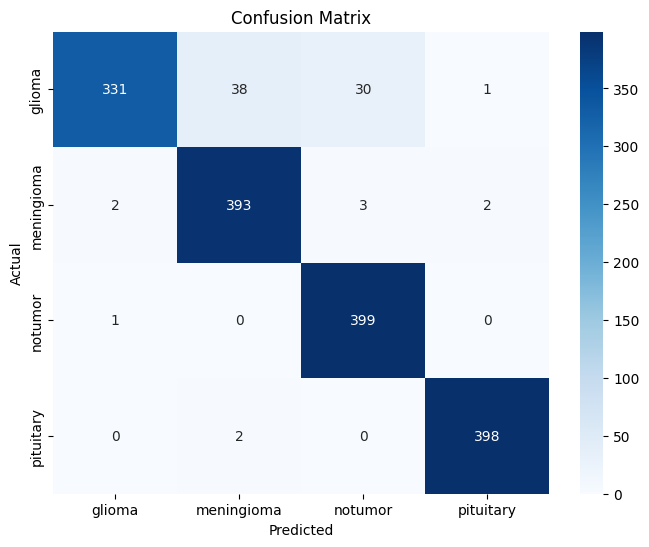

In [61]:
cm = confusion_matrix(y_true, y_pred)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [69]:
print(classification_report(y_true, y_pred, 
                            target_names = ['glioma', 'meningioma', 'notumor', 'pituitary']))

              precision    recall  f1-score   support

      glioma       0.99      0.83      0.90       400
  meningioma       0.91      0.98      0.94       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



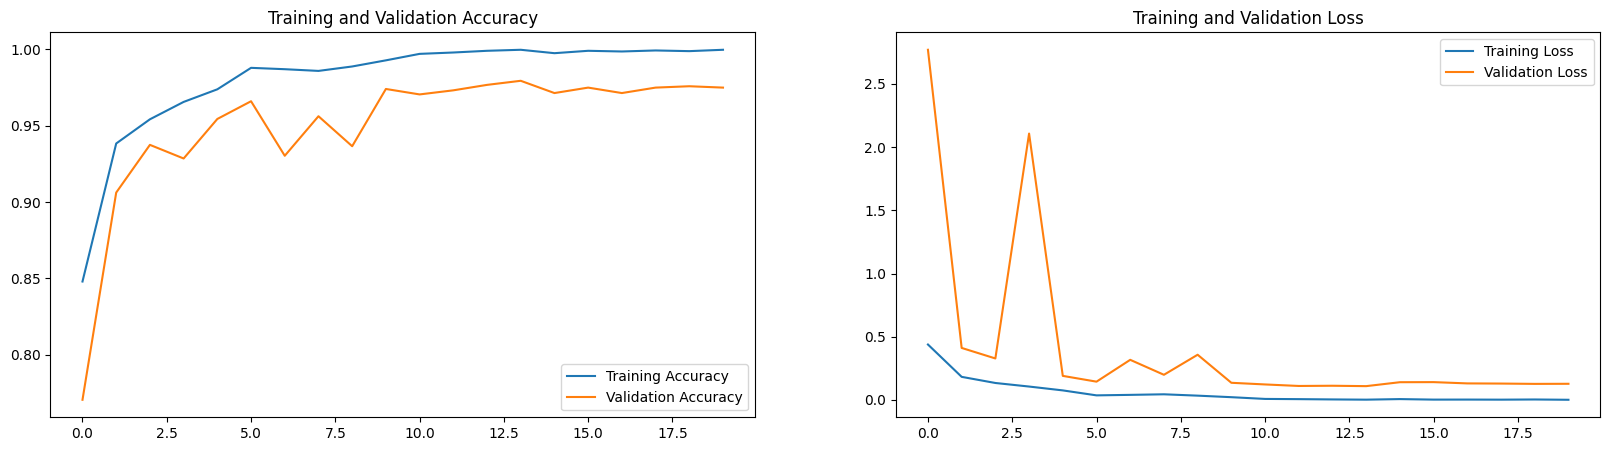

In [63]:
ResNet_acc = fine_history.history['accuracy']
ResNet_val_acc = fine_history.history['val_accuracy']
ResNet_loss = fine_history.history['loss']
ResNet_val_loss = fine_history.history['val_loss']

epochs_range = range(len(ResNet_acc))

plt.figure(figsize = (20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, ResNet_acc, label = 'Training Accuracy')
plt.plot(epochs_range, ResNet_val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, ResNet_loss, label = 'Training Loss')
plt.plot(epochs_range, ResNet_val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

In [76]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

mis_images = []
mis_true = []
mis_pred = []
mis_conf = []

for images, labels in test_ds:
    preds = ResNet_fine_model.predict(images)

    for i in range(len(images)):
        true_label = np.argmax(labels[i])
        pred_label = np.argmax(preds[i])
        confidence = np.max(preds[i])

        if true_label != pred_label:
            mis_images.append(images[i].numpy())
            mis_true.append(true_label)
            mis_pred.append(pred_label)
            mis_conf.append(confidence)

mis_images = np.array(mis_images)

print("Total Misclassified:", len(mis_images))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

### recall for glioma is a concern